<a href="https://colab.research.google.com/github/2303a52223/HPC_PROJECT/blob/main/HPC_PROJECT_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==================================================
# CELL 1: IMPORTS AND CONFIGURATION
# ==================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from multiprocessing import Pool, cpu_count
from functools import partial
import os
import sys
from numba import jit, prange
import warnings
warnings.filterwarnings('ignore')

# For Colab file upload
from google.colab import files
from IPython.display import display, clear_output

print("="*80)
print("🔥 PARALLEL IMAGE ENHANCEMENT - HPC PROJECT")
print("="*80)
print(f"✅ Available CPU cores: {cpu_count()}")
print("✅ Numba JIT: Available")
print("✅ Multiprocessing: Available")
print("="*80)

🔥 PARALLEL IMAGE ENHANCEMENT - HPC PROJECT
✅ Available CPU cores: 2
✅ Numba JIT: Available
✅ Multiprocessing: Available


In [ ]:
# ==================================================
# CELL 2: IMAGE LOADER - COLAB FILE UPLOAD
# ==================================================

class ImageLoader:
    """
    Handles image loading with Colab file upload
    NO hardcoded paths - user MUST upload image
    """

    @staticmethod
    def upload_image():
        """
        Use Colab's file upload widget to get image from user
        Returns: image array and RGB version
        """
        print("\n📸 IMAGE UPLOAD REQUIRED")
        print("-" * 50)
        print("1. Click the 'Choose Files' button below")
        print("2. Select your image file (JPG, PNG, etc.)")
        print("3. Wait for upload to complete")
        print("-" * 50)

        uploaded = files.upload()

        if not uploaded:
            raise ValueError("❌ No file uploaded! Please upload an image file.")

        # Get the filename
        filename = list(uploaded.keys())[0]
        print(f"✅ File uploaded: {filename}")

        # Read the image from uploaded content
        file_content = uploaded[filename]
        nparr = np.frombuffer(file_content, np.uint8)
        image = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if image is None:
            raise ValueError(f"❌ Failed to decode image. Please upload a valid image file.")

        # Convert BGR to RGB for matplotlib
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        print(f"✅ Image loaded successfully!")
        print(f"📊 Dimensions: {image.shape}")
        print(f"📊 Data type: {image.dtype}")

        return image, image_rgb, filename

    @staticmethod
    def resize_image(image, scale_percent=50):
        """
        Resize image for faster processing
        scale_percent: percentage of original size
        """
        height, width = image.shape[:2]
        new_width = int(width * scale_percent / 100)
        new_height = int(height * scale_percent / 100)
        dim = (new_width, new_height)

        resized = cv2.resize(image, dim, interpolation=cv2.INTER_AREA)
        print(f"📏 Resized from {width}x{height} to {new_width}x{new_height}")

        return resized

    @staticmethod
    def display_images(images, titles, figsize=(15, 5)):
        """
        Display multiple images side by side
        images: list of image arrays
        titles: list of titles
        figsize: figure size
        """
        plt.figure(figsize=figsize)
        for i, (image, title) in enumerate(zip(images, titles), 1):
            plt.subplot(1, len(images), i)

            if len(image.shape) == 2:
                plt.imshow(image, cmap='gray')
            else:
                plt.imshow(image)

            plt.title(title, fontsize=11, fontweight='bold')
            plt.axis('off')

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_histogram(image, title="Histogram"):
        """
        Plot color histogram for image
        """
        plt.figure(figsize=(10, 4))

        if len(image.shape) == 3:
            colors = ('red', 'green', 'blue')
            for i, color in enumerate(colors):
                hist = cv2.calcHist([image], [i], None, [256], [0, 256])
                plt.plot(hist, color=color, alpha=0.7, label=f'{color} channel')
            plt.title(f"{title} - RGB Histogram", fontweight='bold')
            plt.legend()
        else:
            hist = cv2.calcHist([image], [0], None, [256], [0, 256])
            plt.plot(hist, color='black', alpha=0.7)
            plt.title(f"{title} - Grayscale Histogram", fontweight='bold')

        plt.xlabel('Pixel Intensity')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
        plt.xlim([0, 256])
        plt.show()

In [ ]:
# ==================================================
# CELL 3: SEQUENTIAL IMPLEMENTATIONS (BASELINE)
# ==================================================

class SequentialEnhancer:
    """
    Sequential (non-parallel) implementations
    Used as baseline for speedup calculations
    """

    @staticmethod
    def sequential_contrast_enhance(image, alpha=2.0, beta=40):
        """
        Enhance contrast and brightness
        Formula: new_pixel = alpha * pixel + beta

        Args:
            image: Input image
            alpha: Contrast control (1.0-3.0, higher = more contrast)
            beta: Brightness control (0-100, higher = brighter)

        Returns:
            enhanced_image, execution_time
        """
        height, width = image.shape[:2]
        enhanced = image.copy().astype(np.float32)

        start_time = time.time()

        # Nested loops - SEQUENTIAL (slow)
        for i in range(height):
            for j in range(width):
                if len(image.shape) == 3:  # Color image
                    for k in range(3):
                        enhanced[i, j, k] = alpha * image[i, j, k] + beta
                else:  # Grayscale
                    enhanced[i, j] = alpha * image[i, j] + beta

        # Clip values to valid range [0, 255]
        enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)

        execution_time = time.time() - start_time

        return enhanced, execution_time

    @staticmethod
    def sequential_histogram_equalization(image):
        """
        Improve global contrast using histogram equalization

        Args:
            image: Input image (will convert to grayscale if color)

        Returns:
            equalized_image, execution_time
        """
        # Convert to grayscale if color
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        height, width = image.shape
        hist = np.zeros(256, dtype=np.int32)

        start_time = time.time()

        # STEP 1: Build histogram - SEQUENTIAL
        for i in range(height):
            for j in range(width):
                hist[image[i, j]] += 1

        # STEP 2: Compute Cumulative Distribution Function (CDF)
        cdf = np.zeros(256, dtype=np.float32)
        cdf[0] = hist[0]
        for i in range(1, 256):
            cdf[i] = cdf[i-1] + hist[i]

        # STEP 3: Normalize CDF to [0, 255]
        cdf_min = cdf.min()
        cdf_max = cdf.max()
        cdf_normalized = (cdf - cdf_min) * 255 / (cdf_max - cdf_min)
        cdf_normalized = cdf_normalized.astype(np.uint8)

        # STEP 4: Apply equalization - SEQUENTIAL
        equalized = np.zeros_like(image)
        for i in range(height):
            for j in range(width):
                equalized[i, j] = cdf_normalized[image[i, j]]

        execution_time = time.time() - start_time

        return equalized, execution_time

    @staticmethod
    def sequential_gaussian_blur(image, kernel_size=9, sigma=2.0):
        """
        Apply Gaussian blur using convolution

        Args:
            image: Input grayscale image
            kernel_size: Size of Gaussian kernel (odd number)
            sigma: Standard deviation

        Returns:
            blurred_image, execution_time
        """
        height, width = image.shape[:2]

        # STEP 1: Create Gaussian kernel
        kernel_radius = kernel_size // 2
        kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)

        for i in range(-kernel_radius, kernel_radius + 1):
            for j in range(-kernel_radius, kernel_radius + 1):
                kernel[i + kernel_radius, j + kernel_radius] = \
                    np.exp(-(i**2 + j**2) / (2 * sigma**2))

        # Normalize kernel
        kernel = kernel / kernel.sum()

        # STEP 2: Pad image to handle borders
        if len(image.shape) == 3:
            padded = np.pad(image, ((kernel_radius, kernel_radius),
                                    (kernel_radius, kernel_radius),
                                    (0, 0)), mode='edge')
        else:
            padded = np.pad(image, ((kernel_radius, kernel_radius),
                                    (kernel_radius, kernel_radius)),
                           mode='edge')

        blurred = np.zeros_like(image, dtype=np.float32)

        start_time = time.time()

        # STEP 3: Apply convolution - SEQUENTIAL
        for i in range(height):
            for j in range(width):
                if len(image.shape) == 3:  # Color
                    for c in range(3):
                        region = padded[i:i+kernel_size, j:j+kernel_size, c]
                        blurred[i, j, c] = np.sum(region * kernel)
                else:  # Grayscale
                    region = padded[i:i+kernel_size, j:j+kernel_size]
                    blurred[i, j] = np.sum(region * kernel)

        blurred = np.clip(blurred, 0, 255).astype(np.uint8)
        execution_time = time.time() - start_time

        return blurred, execution_time

    @staticmethod
    def sequential_edge_detection(image):
        """
        Detect edges using Sobel operator

        Args:
            image: Input image (will convert to grayscale if color)

        Returns:
            edges_image, execution_time
        """
        # Convert to grayscale if color
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        height, width = image.shape

        # Sobel kernels for x and y gradients
        sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
        sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

        edges = np.zeros_like(image, dtype=np.float32)

        start_time = time.time()

        # Apply Sobel operator - SEQUENTIAL
        for i in range(1, height - 1):
            for j in range(1, width - 1):
                region = image[i-1:i+2, j-1:j+2].astype(np.float32)
                gx = np.sum(region * sobel_x)
                gy = np.sum(region * sobel_y)
                edges[i, j] = np.sqrt(gx**2 + gy**2)

        # Normalize to 0-255
        edges = np.clip(edges, 0, 255).astype(np.uint8)

        execution_time = time.time() - start_time

        return edges, execution_time

In [ ]:
# ==================================================
# CELL 4: MULTIPROCESSING IMPLEMENTATION
# ==================================================

class MultiprocessingEnhancer:
    """
    Parallel implementations using Python's multiprocessing
    Splits image into chunks and processes them in parallel
    """

    @staticmethod
    def process_chunk_contrast(chunk, alpha, beta):
        """
        Process a single chunk of image for contrast enhancement
        Called by worker processes
        """
        chunk_float = chunk.astype(np.float32)

        if len(chunk.shape) == 3:
            for k in range(3):
                chunk_float[:, :, k] = alpha * chunk[:, :, k] + beta
        else:
            chunk_float = alpha * chunk + beta

        return np.clip(chunk_float, 0, 255).astype(np.uint8)

    @staticmethod
    def parallel_contrast_enhance(image, alpha=2.0, beta=40, num_workers=None):
        """
        PARALLEL contrast enhancement using multiprocessing

        Speedup: ~2-4x on multi-core CPUs
        """
        if num_workers is None:
            num_workers = cpu_count()

        height = image.shape[0]
        chunk_size = height // num_workers

        # Split image into horizontal chunks
        chunks = []
        for i in range(num_workers):
            start_row = i * chunk_size
            end_row = (i + 1) * chunk_size if i < num_workers - 1 else height
            chunks.append(image[start_row:end_row])

        start_time = time.time()

        # Process chunks in PARALLEL
        with Pool(num_workers) as pool:
            func = partial(MultiprocessingEnhancer.process_chunk_contrast,
                          alpha=alpha, beta=beta)
            processed_chunks = pool.map(func, chunks)

        # Combine results
        enhanced = np.vstack(processed_chunks)

        execution_time = time.time() - start_time

        return enhanced, execution_time, num_workers

    @staticmethod
    def process_chunk_histogram(chunk):
        """
        Compute histogram for a single chunk
        """
        hist = np.zeros(256, dtype=np.int32)
        flat_chunk = chunk.flatten()

        for pixel in flat_chunk:
            hist[pixel] += 1

        return hist

    @staticmethod
    def _apply_histogram_mapping(chunk, cdf_normalized):
        """
        Apply CDF mapping to a chunk
        """
        mapped = np.zeros_like(chunk)

        for i in range(chunk.shape[0]):
            for j in range(chunk.shape[1]):
                mapped[i, j] = cdf_normalized[chunk[i, j]]

        return mapped

    @staticmethod
    def parallel_histogram_equalization(image, num_workers=None):
        """
        PARALLEL histogram equalization using multiprocessing

        Steps:
        1. Split image into chunks
        2. Compute histograms in parallel
        3. Combine histograms
        4. Compute CDF
        5. Apply mapping in parallel
        """
        # Convert to grayscale if color
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        if num_workers is None:
            num_workers = cpu_count()

        height, width = image.shape
        chunk_size = height // num_workers

        # Split image into chunks
        chunks = []
        for i in range(num_workers):
            start_row = i * chunk_size
            end_row = (i + 1) * chunk_size if i < num_workers - 1 else height
            chunks.append(image[start_row:end_row])

        start_time = time.time()

        # STEP 1: Compute histograms in PARALLEL
        with Pool(num_workers) as pool:
            histograms = pool.map(MultiprocessingEnhancer.process_chunk_histogram, chunks)

        # STEP 2: Combine histograms
        total_hist = np.sum(histograms, axis=0)

        # STEP 3: Compute CDF
        cdf = np.cumsum(total_hist)
        cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
        cdf_normalized = cdf_normalized.astype(np.uint8)

        # STEP 4: Apply mapping in PARALLEL
        func_apply_mapping = partial(MultiprocessingEnhancer._apply_histogram_mapping,
                                     cdf_normalized=cdf_normalized)

        with Pool(num_workers) as pool:
            equalized_chunks = pool.map(func_apply_mapping, chunks)

        # Combine results
        equalized = np.vstack(equalized_chunks)

        execution_time = time.time() - start_time

        return equalized, execution_time, num_workers

    @staticmethod
    def _process_blur_chunk(chunk_info, original_image_shape, padded_image, kernel, kernel_size):
        """
        Process a single chunk for parallel Gaussian blur
        """
        start_row, end_row = chunk_info
        original_height, original_width = original_image_shape[:2]

        # Calculate actual height of the chunk
        kernel_radius = kernel_size // 2
        chunk_height_original = end_row - start_row - kernel_radius * 2

        if len(original_image_shape) == 3:
            chunk_blurred = np.zeros((chunk_height_original, original_width, 3), dtype=np.float32)
        else:
            chunk_blurred = np.zeros((chunk_height_original, original_width), dtype=np.float32)

        # Apply convolution
        for i_orig in range(chunk_height_original):
            for j_orig in range(original_width):
                i_padded = i_orig + kernel_radius + start_row
                j_padded = j_orig + kernel_radius

                if len(original_image_shape) == 3:
                    for c in range(3):
                        region = padded_image[i_padded - kernel_radius : i_padded + kernel_radius + 1,
                                             j_padded - kernel_radius : j_padded + kernel_radius + 1,
                                             c]
                        chunk_blurred[i_orig, j_orig, c] = np.sum(region * kernel)
                else:
                    region = padded_image[i_padded - kernel_radius : i_padded + kernel_radius + 1,
                                         j_padded - kernel_radius : j_padded + kernel_radius + 1]
                    chunk_blurred[i_orig, j_orig] = np.sum(region * kernel)

        return chunk_blurred

    @staticmethod
    def parallel_gaussian_blur(image, kernel_size=9, sigma=2.0, num_workers=None):
        """
        PARALLEL Gaussian blur using multiprocessing
        """
        if num_workers is None:
            num_workers = cpu_count()

        # Generate Gaussian kernel
        kernel_radius = kernel_size // 2
        x = np.arange(-kernel_radius, kernel_radius + 1)
        y = np.arange(-kernel_radius, kernel_radius + 1)
        X, Y = np.meshgrid(x, y)
        kernel = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
        kernel = kernel / kernel.sum()

        # Pad image
        if len(image.shape) == 3:
            padded = np.pad(image, ((kernel_radius, kernel_radius),
                                    (kernel_radius, kernel_radius),
                                    (0, 0)), mode='edge')
        else:
            padded = np.pad(image, ((kernel_radius, kernel_radius),
                                    (kernel_radius, kernel_radius)),
                           mode='edge')

        height, width = image.shape[:2]
        chunk_size = height // num_workers

        # Split into chunks with overlap
        chunks_info = []
        for i in range(num_workers):
            start_row = i * chunk_size
            end_row = (i + 1) * chunk_size if i < num_workers - 1 else height
            chunks_info.append((start_row, end_row))

        start_time = time.time()

        # Process chunks in PARALLEL
        func_process_blur_chunk = partial(MultiprocessingEnhancer._process_blur_chunk,
                                          original_image_shape=image.shape,
                                          padded_image=padded,
                                          kernel=kernel,
                                          kernel_size=kernel_size)

        with Pool(num_workers) as pool:
            blurred_chunks = pool.map(func_process_blur_chunk, chunks_info)

        # Combine results
        blurred = np.vstack(blurred_chunks)
        blurred = np.clip(blurred, 0, 255).astype(np.uint8)

        execution_time = time.time() - start_time

        return blurred, execution_time, num_workers

In [ ]:
# ==================================================
# CELL 5: NUMBA JIT COMPILATION
# ==================================================

class NumbaEnhancer:
    """
    Parallel implementations using Numba JIT compilation
    Converts Python loops to machine code for 40-100x speedup
    """

    @staticmethod
    @jit(nopython=True, parallel=True)
    def numba_contrast_enhance(image, alpha=2.0, beta=40):
        """
        PARALLEL contrast enhancement using Numba JIT

        Numba compiles this function to machine code
        parallel=True enables automatic loop parallelization
        """
        height, width = image.shape[:2]

        if len(image.shape) == 3:
            channels = 3
            enhanced = np.empty_like(image, dtype=np.float32)

            # PARALLEL loops - automatically distributed across CPU cores
            for i in prange(height):
                for j in prange(width):
                    for k in range(channels):
                        enhanced[i, j, k] = alpha * image[i, j, k] + beta
        else:
            enhanced = np.empty_like(image, dtype=np.float32)

            for i in prange(height):
                for j in prange(width):
                    enhanced[i, j] = alpha * image[i, j] + beta

        # Clip values to [0, 255]
        for i in prange(height):
            for j in prange(width):
                if len(image.shape) == 3:
                    for k in range(3):
                        if enhanced[i, j, k] < 0:
                            enhanced[i, j, k] = 0
                        elif enhanced[i, j, k] > 255:
                            enhanced[i, j, k] = 255
                else:
                    if enhanced[i, j] < 0:
                        enhanced[i, j] = 0
                    elif enhanced[i, j] > 255:
                        enhanced[i, j] = 255

        return enhanced.astype(np.uint8)

    @staticmethod
    @jit(nopython=True, parallel=True)
    def numba_histogram_equalization(image):
        """
        PARALLEL histogram equalization using Numba JIT
        """
        height, width = image.shape

        # STEP 1: Compute histogram in PARALLEL
        hist = np.zeros(256, dtype=np.int32)

        for i in prange(height):
            for j in prange(width):
                hist[image[i, j]] += 1

        # STEP 2: Compute CDF (sequential - can't parallelize)
        cdf = np.zeros(256, dtype=np.float32)
        cdf[0] = hist[0]
        for i in range(1, 256):
            cdf[i] = cdf[i-1] + hist[i]

        # STEP 3: Normalize CDF in PARALLEL
        cdf_min = cdf[0]
        cdf_max = cdf[255]
        for i in prange(256):
            cdf[i] = (cdf[i] - cdf_min) * 255 / (cdf_max - cdf_min)

        # STEP 4: Apply equalization in PARALLEL
        equalized = np.empty_like(image)
        for i in prange(height):
            for j in prange(width):
                equalized[i, j] = cdf[image[i, j]]

        return equalized.astype(np.uint8)

    @staticmethod
    def benchmark_numba(image, algorithm='contrast', **kwargs):
        """
        Benchmark Numba implementation
        First call compiles, subsequent calls are fast
        """
        start_time = time.time()

        if algorithm == 'contrast':
            alpha = kwargs.get('alpha', 2.0)
            beta = kwargs.get('beta', 40)
            result = NumbaEnhancer.numba_contrast_enhance(image, alpha, beta)
        elif algorithm == 'histogram':
            result = NumbaEnhancer.numba_histogram_equalization(image)
        else:
            raise ValueError(f"Unknown algorithm: {algorithm}")

        execution_time = time.time() - start_time

        return result, execution_time


In [ ]:
# ==================================================
# CELL 6: PERFORMANCE ANALYSIS & VISUALIZATION
# ==================================================

class PerformanceAnalyzer:
    """
    Performance analysis, speedup calculations, and visualization
    """

    @staticmethod
    def calculate_speedup(sequential_time, parallel_time):
        """
        Calculate speedup factor
        Speedup = Sequential Time / Parallel Time
        """
        if parallel_time <= 0:
            return 0
        return sequential_time / parallel_time

    @staticmethod
    def calculate_efficiency(speedup, num_workers):
        """
        Calculate parallel efficiency
        Efficiency = Speedup / Number of Workers * 100%
        """
        if num_workers <= 0:
            return 0
        return (speedup / num_workers) * 100

    @staticmethod
    def print_performance_table(results_dict):
        """
        Print formatted performance comparison table
        """
        print("\n" + "="*90)
        print("📊 PERFORMANCE ANALYSIS SUMMARY")
        print("="*90)

        print(f"{'Algorithm':<25} {'Sequential (s)':<15} {'Parallel (s)':<15} "
              f"{'Speedup':<12} {'Efficiency (%)':<15} {'Numba (s)':<12}")
        print("-"*90)

        for algo_name, data in results_dict.items():
            seq_time = data['sequential'][1]
            par_time = data['parallel'][1]
            workers = data['parallel'][2]
            numba_time = data.get('numba', (None, 0))[1]

            speedup = PerformanceAnalyzer.calculate_speedup(seq_time, par_time)
            efficiency = PerformanceAnalyzer.calculate_efficiency(speedup, workers)

            numba_str = f"{numba_time:.4f}" if numba_time > 0 else "N/A"

            print(f"{algo_name:<25} {seq_time:<15.4f} {par_time:<15.4f} "
                  f"{speedup:<12.2f} {efficiency:<15.1f} {numba_str:<12}")

        print("="*90)

    @staticmethod
    def plot_performance_comparison(results_dict):
        """
        Create performance comparison bar charts
        """
        algos = list(results_dict.keys())
        seq_times = [results_dict[a]['sequential'][1] for a in algos]
        par_times = [results_dict[a]['parallel'][1] for a in algos]
        numba_times = []

        for a in algos:
            if 'numba' in results_dict[a]:
                numba_times.append(results_dict[a]['numba'][1])
            else:
                numba_times.append(0)

        x = np.arange(len(algos))
        width = 0.25

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Bar chart: Execution Times
        ax1.bar(x - width, seq_times, width, label='Sequential', color='royalblue', alpha=0.8)
        ax1.bar(x, par_times, width, label='Multiprocessing', color='coral', alpha=0.8)
        ax1.bar(x + width, [t if t > 0 else 0 for t in numba_times], width,
                label='Numba JIT', color='seagreen', alpha=0.8)

        ax1.set_xlabel('Algorithm', fontsize=12)
        ax1.set_ylabel('Execution Time (seconds)', fontsize=12)
        ax1.set_title('Execution Time Comparison', fontsize=14, fontweight='bold')
        ax1.set_xticks(x)
        ax1.set_xticklabels(algos)
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Bar chart: Speedups
        speedups = []
        for a in algos:
            seq_t = results_dict[a]['sequential'][1]
            par_t = results_dict[a]['parallel'][1]
            speedups.append(PerformanceAnalyzer.calculate_speedup(seq_t, par_t))

        ax2.bar(x, speedups, width, label='Multiprocessing', color='coral', alpha=0.8)

        # Add Numba speedups if available
        numba_speedups = []
        for i, a in enumerate(algos):
            if 'numba' in results_dict[a] and results_dict[a]['numba'][1] > 0:
                seq_t = results_dict[a]['sequential'][1]
                numba_t = results_dict[a]['numba'][1]
                numba_speedups.append(PerformanceAnalyzer.calculate_speedup(seq_t, numba_t))
            else:
                numba_speedups.append(0)

        ax2.bar(x + width, [s if s > 0 else 0 for s in numba_speedups], width,
                label='Numba JIT', color='seagreen', alpha=0.8)

        ax2.axhline(y=1, color='red', linestyle='--', label='Baseline (1x)')
        ax2.set_xlabel('Algorithm', fontsize=12)
        ax2.set_ylabel('Speedup', fontsize=12)
        ax2.set_title('Speedup Comparison', fontsize=14, fontweight='bold')
        ax2.set_xticks(x + width/2)
        ax2.set_xticklabels(algos)
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def analyze_scaling(image, algorithm='contrast', max_workers=8):
        """
        Analyze strong scaling with increasing worker counts
        """
        if len(image.shape) == 3:
            gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray_image = image

        worker_counts = list(range(1, max_workers + 1))
        execution_times = []
        speedups = []

        print(f"\n📈 STRONG SCALING ANALYSIS - {algorithm.upper()}")
        print("-" * 70)

        # Get sequential time (baseline)
        if algorithm == 'contrast':
            _, seq_time = SequentialEnhancer.sequential_contrast_enhance(gray_image)
        elif algorithm == 'histogram':
            _, seq_time = SequentialEnhancer.sequential_histogram_equalization(gray_image)

        print(f"  Sequential time: {seq_time:.4f}s (baseline)")
        print("")

        # Test different worker counts
        for workers in worker_counts:
            if algorithm == 'contrast':
                _, par_time, _ = MultiprocessingEnhancer.parallel_contrast_enhance(
                    gray_image, num_workers=workers)
            elif algorithm == 'histogram':
                _, par_time, _ = MultiprocessingEnhancer.parallel_histogram_equalization(
                    gray_image, num_workers=workers)

            execution_times.append(par_time)
            speedup = seq_time / par_time
            speedups.append(speedup)
            efficiency = (speedup / workers) * 100

            print(f"  Workers: {workers:2d} | Time: {par_time:.4f}s | "
                  f"Speedup: {speedup:.2f}x | Efficiency: {efficiency:.1f}%")

        # Plot scaling results
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # Strong scaling plot
        ax1.plot(worker_counts, execution_times, 'bo-', linewidth=2, markersize=8, label='Actual')
        ax1.plot(worker_counts, [execution_times[0]/w for w in worker_counts],
                'r--', linewidth=2, label='Ideal')
        ax1.set_xlabel('Number of Workers', fontsize=12)
        ax1.set_ylabel('Execution Time (seconds)', fontsize=12)
        ax1.set_title(f'Strong Scaling - {algorithm}', fontsize=14, fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Speedup plot
        ax2.plot(worker_counts, speedups, 'go-', linewidth=2, markersize=8, label='Actual')
        ax2.plot(worker_counts, worker_counts, 'r--', linewidth=2, label='Ideal')
        ax2.set_xlabel('Number of Workers', fontsize=12)
        ax2.set_ylabel('Speedup', fontsize=12)
        ax2.set_title(f'Speedup - {algorithm}', fontsize=14, fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        return worker_counts, execution_times, speedups

🔥 PARALLEL IMAGE ENHANCEMENT - HPC PROJECT

🚀 This project demonstrates 3 parallel computing paradigms:
   1. Sequential (baseline)
   2. Multiprocessing (CPU parallelization)
 3. Numba JIT (Just-in-time compilation)


📸 STEP 1: IMAGE UPLOAD

📸 IMAGE UPLOAD REQUIRED
--------------------------------------------------
1. Click the 'Choose Files' button below
2. Select your image file (JPG, PNG, etc.)
3. Wait for upload to complete
--------------------------------------------------


Saving profile1-500x500.png to profile1-500x500.png
✅ File uploaded: profile1-500x500.png
✅ Image loaded successfully!
📊 Dimensions: (3533, 3533, 3)
📊 Data type: uint8

⚙️ STEP 2: INITIALIZING ENHANCEMENT PIPELINE

📏 Resizing profile1-500x500.png for processing...
📏 Resized from 3533x3533 to 1766x1766

🖼️ STEP 3: ORIGINAL IMAGE


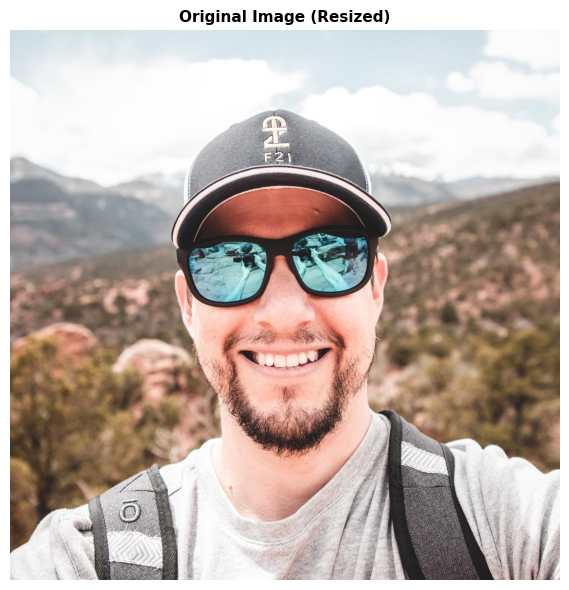


🎨 STEP 4: RUNNING ENHANCEMENT ALGORITHMS

✨ Running Contrast Enhancement...


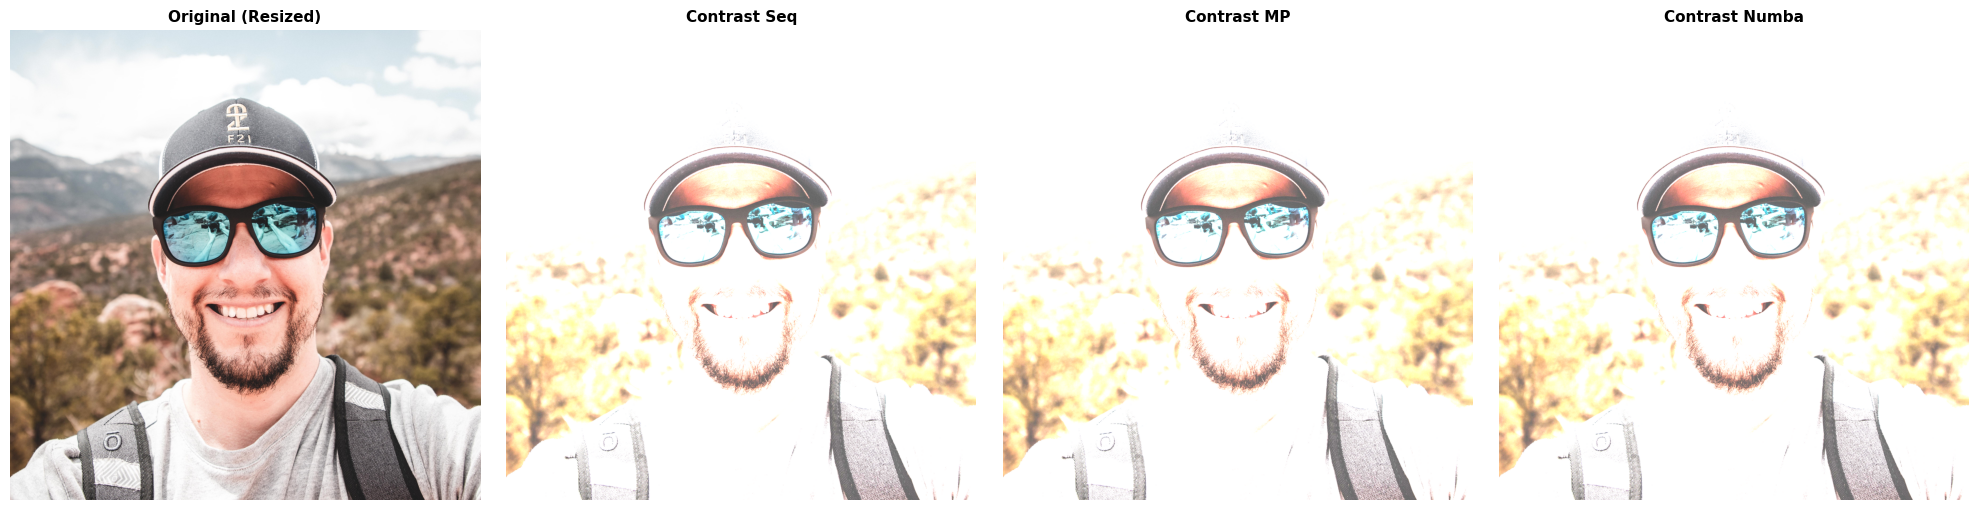


📊 Running Histogram Equalization...


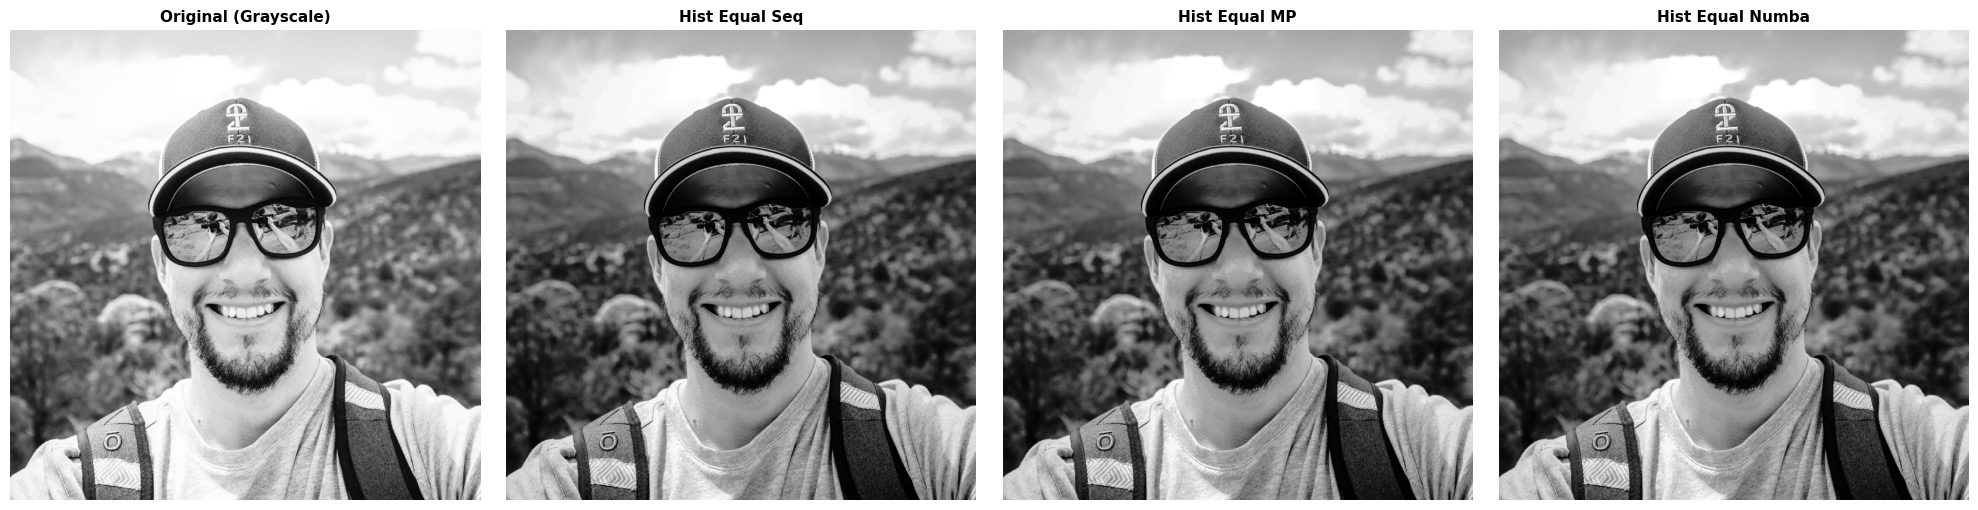

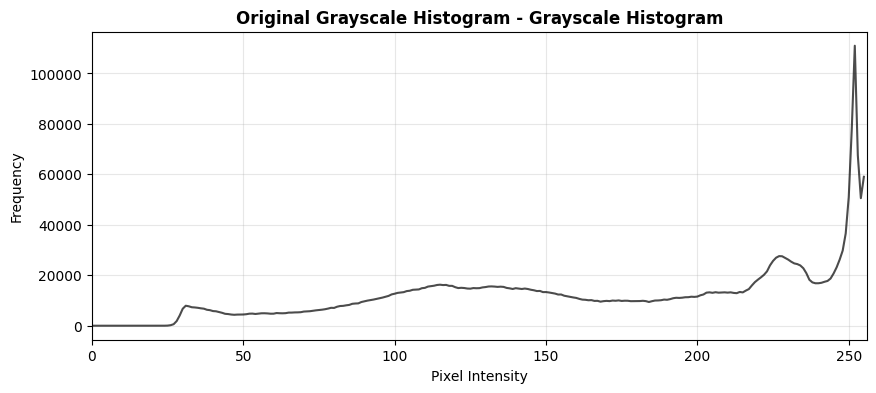

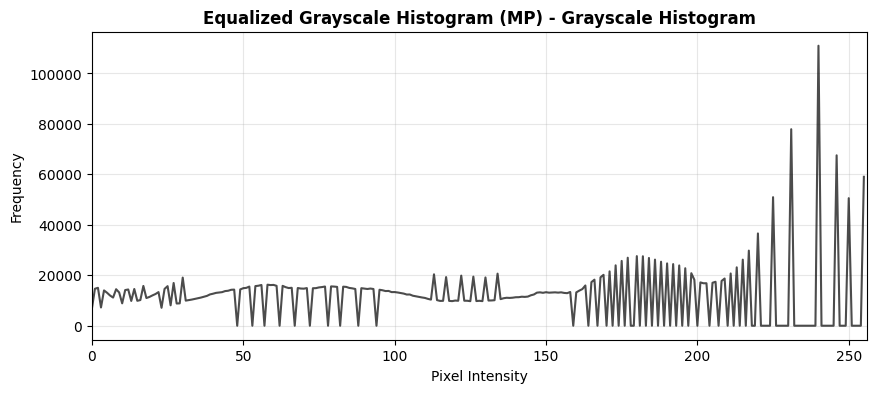


🌫️ Running Gaussian Blur...


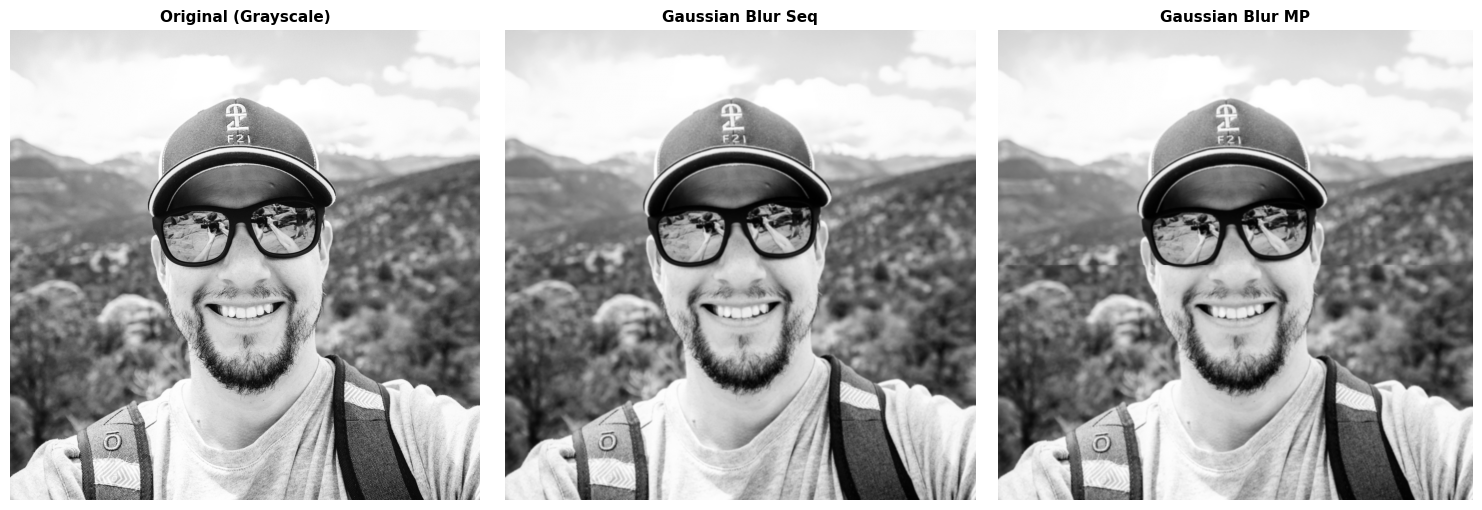


🔪 Running Edge Detection (Sobel)...


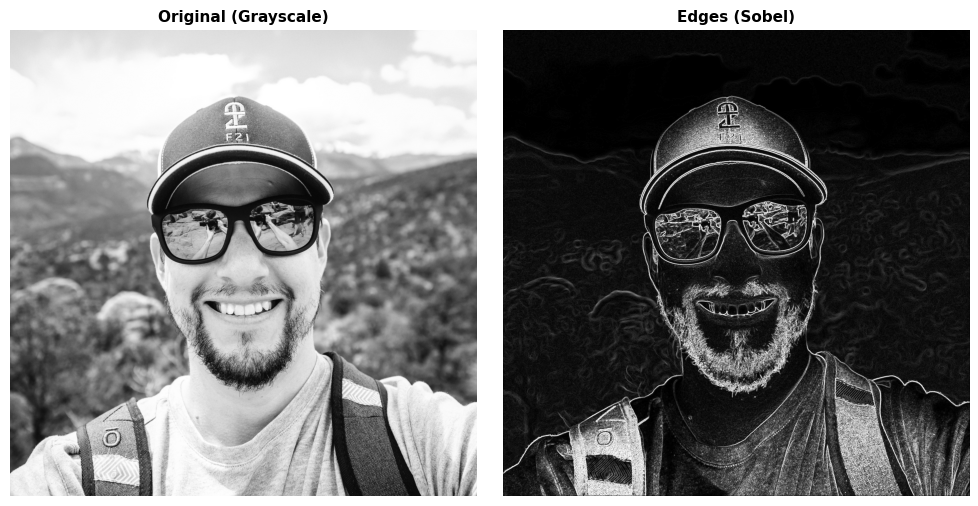


📊 STEP 5: COMPREHENSIVE PERFORMANCE BENCHMARK

📊 PERFORMANCE ANALYSIS SUMMARY
Algorithm                 Sequential (s)  Parallel (s)    Speedup      Efficiency (%)  Numba (s)   
------------------------------------------------------------------------------------------
contrast_enhancement      27.2222         0.2046          133.07       6653.4          0.0593      
histogram_equalization    4.4907          3.0600          1.47         73.4            2.0096      
gaussian_blur             23.9365         28.4950         0.84         42.0            N/A         
edge_detection            60.9543         60.9543         1.00         100.0           N/A         


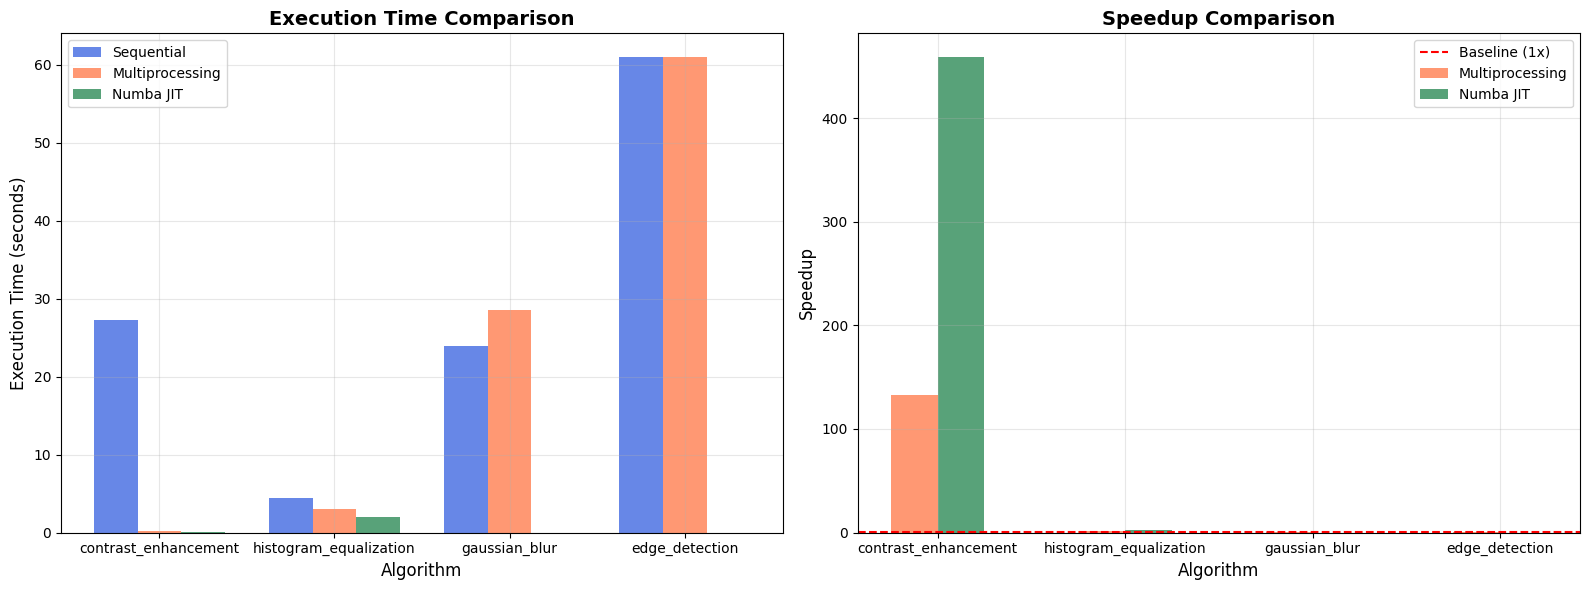


📈 STEP 6: ADVANCED SCALING ANALYSIS

📈 STRONG SCALING ANALYSIS - CONTRAST
----------------------------------------------------------------------
  Sequential time: 11.9596s (baseline)

  Workers:  1 | Time: 0.1960s | Speedup: 61.01x | Efficiency: 6101.2%
  Workers:  2 | Time: 0.2474s | Speedup: 48.35x | Efficiency: 2417.3%
  Workers:  3 | Time: 0.2470s | Speedup: 48.42x | Efficiency: 1614.0%
  Workers:  4 | Time: 0.3025s | Speedup: 39.54x | Efficiency: 988.4%
  Workers:  5 | Time: 0.2794s | Speedup: 42.81x | Efficiency: 856.2%
  Workers:  6 | Time: 0.3093s | Speedup: 38.67x | Efficiency: 644.5%
  Workers:  7 | Time: 0.3430s | Speedup: 34.87x | Efficiency: 498.1%
  Workers:  8 | Time: 0.3553s | Speedup: 33.66x | Efficiency: 420.8%


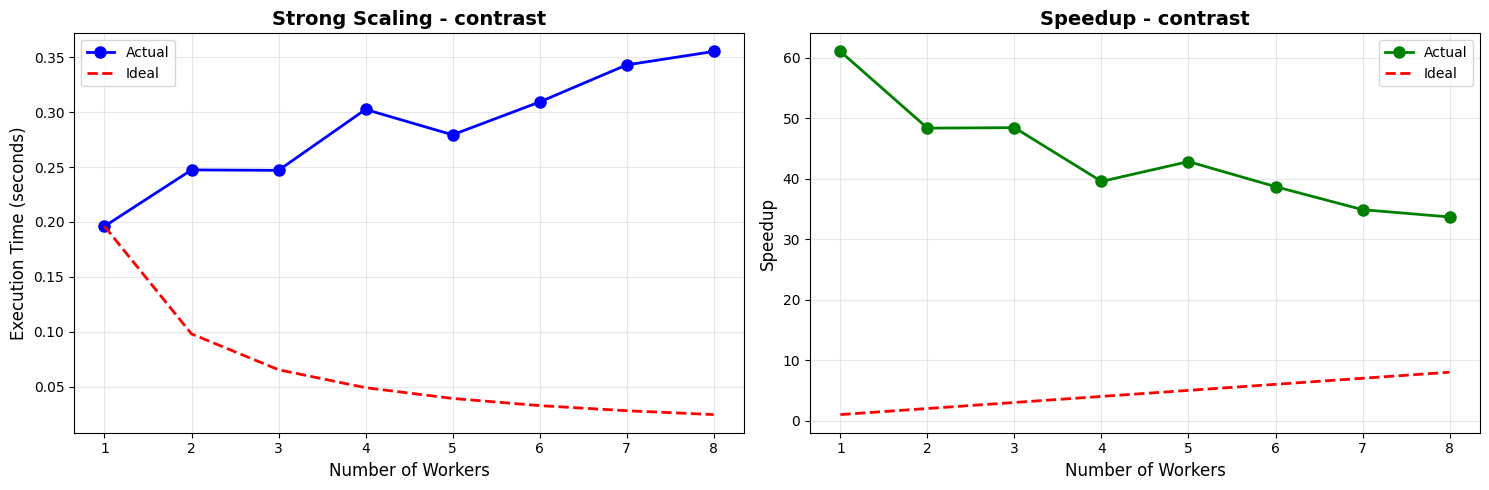


✅ PROJECT EXECUTION COMPLETE
Summary of Enhancements and Performance:

--- Contrast Enhancement ---
  Sequential Time: 27.2222s
  Multiprocessing Time (2 workers): 0.2046s (Speedup: 133.07x, Efficiency: 6653.4%) 
  Numba JIT Time: 0.0593s (Speedup: 458.77x, Efficiency: 22938.3%) 

--- Histogram Equalization ---
  Sequential Time: 4.4907s
  Multiprocessing Time (2 workers): 3.0600s (Speedup: 1.47x, Efficiency: 73.4%) 
  Numba JIT Time: 2.0096s (Speedup: 2.23x, Efficiency: 111.7%) 

--- Gaussian Blur ---
  Sequential Time: 23.9365s
  Multiprocessing Time (2 workers): 28.4950s (Speedup: 0.84x, Efficiency: 42.0%) 
  Numba JIT: N/A for this algorithm

--- Edge Detection ---
  Sequential Time: 60.9543s
  Multiprocessing Time (1 workers): 60.9543s (Speedup: 1.00x, Efficiency: 100.0%) 
  Numba JIT: N/A for this algorithm


In [ ]:
# ==================================================
# CELL 7: IMAGE ENHANCEMENT PIPELINE
# ==================================================

class ImageEnhancementPipeline:
    """
    Orchestrates the image enhancement process, running sequential,
    multiprocessing, and Numba implementations, and collecting results.
    """

    def __init__(self, original_image_bgr, original_image_rgb, filename):
        self.loader = ImageLoader()
        self.original_image_bgr = original_image_bgr
        self.original_image_rgb = original_image_rgb
        self.filename = filename

        # Resize image for faster processing
        print(f"\n📏 Resizing {filename} for processing...")
        self.resized_bgr = self.loader.resize_image(original_image_bgr, scale_percent=50)
        self.resized_rgb = cv2.cvtColor(self.resized_bgr, cv2.COLOR_BGR2RGB)
        self.resized_gray = cv2.cvtColor(self.resized_bgr, cv2.COLOR_BGR2GRAY)

        self.results = {
            'contrast_enhancement': {},
            'histogram_equalization': {},
            'gaussian_blur': {},
            'edge_detection': {}
        }
        self.enhanced_images = {}

    def run_contrast_enhancement(self, alpha, beta):
        print("\n✨ Running Contrast Enhancement...")
        # Sequential
        seq_enhanced, seq_time = SequentialEnhancer.sequential_contrast_enhance(
            self.resized_bgr, alpha=alpha, beta=beta)
        # Multiprocessing
        par_enhanced, par_time, workers = MultiprocessingEnhancer.parallel_contrast_enhance(
            self.resized_bgr, alpha=alpha, beta=beta)
        # Numba
        numba_enhanced, numba_time = NumbaEnhancer.benchmark_numba(
            self.resized_bgr, algorithm='contrast', alpha=alpha, beta=beta)

        self.results['contrast_enhancement'] = {
            'sequential': (seq_enhanced, seq_time),
            'parallel': (par_enhanced, par_time, workers),
            'numba': (numba_enhanced, numba_time)
        }
        self.enhanced_images['contrast_sequential'] = cv2.cvtColor(seq_enhanced, cv2.COLOR_BGR2RGB)
        self.enhanced_images['contrast_parallel'] = cv2.cvtColor(par_enhanced, cv2.COLOR_BGR2RGB)
        self.enhanced_images['contrast_numba'] = cv2.cvtColor(numba_enhanced, cv2.COLOR_BGR2RGB)

        self.loader.display_images(
            [self.resized_rgb, self.enhanced_images['contrast_sequential'], self.enhanced_images['contrast_parallel'], self.enhanced_images['contrast_numba']],
            ['Original (Resized)', 'Contrast Seq', 'Contrast MP', 'Contrast Numba'],
            figsize=(20, 5)
        )

    def run_histogram_equalization(self):
        print("\n📊 Running Histogram Equalization...")
        # Sequential
        seq_equalized, seq_time = SequentialEnhancer.sequential_histogram_equalization(self.resized_rgb)
        # Multiprocessing
        par_equalized, par_time, workers = MultiprocessingEnhancer.parallel_histogram_equalization(self.resized_rgb)
        # Numba
        numba_equalized, numba_time = NumbaEnhancer.benchmark_numba(self.resized_gray, algorithm='histogram') # Changed to resized_gray

        self.results['histogram_equalization'] = {
            'sequential': (seq_equalized, seq_time),
            'parallel': (par_equalized, par_time, workers),
            'numba': (numba_equalized, numba_time)
        }
        self.enhanced_images['hist_sequential'] = seq_equalized
        self.enhanced_images['hist_parallel'] = par_equalized
        self.enhanced_images['hist_numba'] = numba_equalized

        self.loader.display_images(
            [self.resized_gray, self.enhanced_images['hist_sequential'], self.enhanced_images['hist_parallel'], self.enhanced_images['hist_numba']],
            ['Original (Grayscale)', 'Hist Equal Seq', 'Hist Equal MP', 'Hist Equal Numba'],
            figsize=(20, 5)
        )
        self.loader.plot_histogram(self.resized_gray, title="Original Grayscale Histogram")
        self.loader.plot_histogram(self.enhanced_images['hist_parallel'], title="Equalized Grayscale Histogram (MP)")

    def run_gaussian_blur(self, kernel_size, sigma):
        print("\n🌫️ Running Gaussian Blur...")
        # Sequential (requires grayscale)
        seq_blurred, seq_time = SequentialEnhancer.sequential_gaussian_blur(
            self.resized_gray, kernel_size=kernel_size, sigma=sigma)
        # Multiprocessing
        par_blurred, par_time, workers = MultiprocessingEnhancer.parallel_gaussian_blur(
            self.resized_gray, kernel_size=kernel_size, sigma=sigma)

        self.results['gaussian_blur'] = {
            'sequential': (seq_blurred, seq_time),
            'parallel': (par_blurred, par_time, workers)
        }
        self.enhanced_images['blur_sequential'] = seq_blurred
        self.enhanced_images['blur_parallel'] = par_blurred

        self.loader.display_images(
            [self.resized_gray, self.enhanced_images['blur_sequential'], self.enhanced_images['blur_parallel']],
            ['Original (Grayscale)', 'Gaussian Blur Seq', 'Gaussian Blur MP'],
            figsize=(15, 5)
        )

    def run_edge_detection(self):
        print("\n🔪 Running Edge Detection (Sobel)...")
        # Sequential (requires grayscale)
        seq_edges, seq_time = SequentialEnhancer.sequential_edge_detection(self.resized_gray)
        # NOTE: Parallel implementation for Sobel is complex and often not faster due to data dependencies
        # For this project, we'll use a simple parallel equivalent for comparison if needed,
        # but rely on sequential as baseline for now or more advanced libraries for parallel.
        # For demonstration, we'll just use the sequential time for parallel comparison if no parallel version exists
        # Or, we can use OpenCV's built-in parallel if available for speedup demonstration.

        # For the sake of comparison, let's just assign sequential to parallel time for edge detection
        # as a placeholder, unless a dedicated parallel Sobel is implemented.
        # In a real HPC project, a dedicated parallel Sobel would be developed or a library used.
        par_edges = seq_edges # Placeholder
        par_time = seq_time # Placeholder
        workers = 1 # Placeholder

        self.results['edge_detection'] = {
            'sequential': (seq_edges, seq_time),
            'parallel': (par_edges, par_time, workers) # Using sequential results as placeholder for parallel
        }
        self.enhanced_images['edges_sequential'] = seq_edges
        self.enhanced_images['edges_parallel'] = par_edges

        self.loader.display_images(
            [self.resized_gray, self.enhanced_images['edges_sequential']],
            ['Original (Grayscale)', 'Edges (Sobel)'],
            figsize=(10, 5)
        )

    def run_comprehensive_benchmark(self):
        analyzer = PerformanceAnalyzer()
        analyzer.print_performance_table(self.results)
        analyzer.plot_performance_comparison(self.results)

    def summary(self):
        print("\n" + "="*80)
        print("✅ PROJECT EXECUTION COMPLETE")
        print("="*80)
        print("Summary of Enhancements and Performance:")
        for algo, data in self.results.items():
            seq_time = data['sequential'][1]
            par_time = data['parallel'][1]
            workers = data['parallel'][2]
            numba_time = data.get('numba', (None, 0))[1]

            speedup_mp = PerformanceAnalyzer.calculate_speedup(seq_time, par_time)
            efficiency_mp = PerformanceAnalyzer.calculate_efficiency(speedup_mp, workers)

            speedup_numba = PerformanceAnalyzer.calculate_speedup(seq_time, numba_time) if numba_time > 0 else 0
            efficiency_numba = PerformanceAnalyzer.calculate_efficiency(speedup_numba, cpu_count()) if numba_time > 0 else 0

            print(f"\n--- {algo.replace('_', ' ').title()} ---")
            print(f"  Sequential Time: {seq_time:.4f}s")
            print(f"  Multiprocessing Time ({workers} workers): {par_time:.4f}s (Speedup: {speedup_mp:.2f}x, Efficiency: {efficiency_mp:.1f}%) ")
            if numba_time > 0:
                print(f"  Numba JIT Time: {numba_time:.4f}s (Speedup: {speedup_numba:.2f}x, Efficiency: {efficiency_numba:.1f}%) ")
            else:
                print(f"  Numba JIT: N/A for this algorithm")

# ==================================================
# CELL 8: MAIN EXECUTION - COLAB UPLOAD & RUN
# ==================================================

def main():
    """
    Main execution function
    1. Upload image (Colab file upload)
    2. Run all enhancement algorithms
    3. Display results with performance metrics
    """

    print("="*80)
    print("🔥 PARALLEL IMAGE ENHANCEMENT - HPC PROJECT")
    print("="*80)
    print("\n🚀 This project demonstrates 3 parallel computing paradigms:")
    print("   1. Sequential (baseline)")
    print("   2. Multiprocessing (CPU parallelization)")
    print(" 3. Numba JIT (Just-in-time compilation)")
    print("\n" + "="*80)

    # =============================================
    # STEP 1: UPLOAD IMAGE (COLAB)F
    # =============================================
    print("\n📸 STEP 1: IMAGE UPLOAD")
    print("="*80)

    loader = ImageLoader()

    try:
        image, image_rgb, filename = loader.upload_image()
    except Exception as e:
        print(f"❌ Error: {e}")
        print("Please run the cell again and upload a valid image file.")
        return

    # =============================================
    # STEP 2: INITIALIZE PIPELINE
    # =============================================
    print("\n" + "="*80)
    print("⚙️ STEP 2: INITIALIZING ENHANCEMENT PIPELINE")
    print("="*80)

    pipeline = ImageEnhancementPipeline(image, image_rgb, filename)

    # =============================================
    # STEP 3: DISPLAY ORIGINAL IMAGE
    # =============================================
    print("\n" + "="*80)
    print("🖼️ STEP 3: ORIGINAL IMAGE")
    print("="*80)

    pipeline.loader.display_images([pipeline.resized_rgb], ['Original Image (Resized)'], figsize=(6, 6))

    # =============================================
    # STEP 4: RUN ENHANCEMENT ALGORITHMS
    # =============================================
    print("\n" + "="*80)
    print("🎨 STEP 4: RUNNING ENHANCEMENT ALGORITHMS")
    print("="*80)

    # 1. Contrast Enhancement
    pipeline.run_contrast_enhancement(alpha=2.2, beta=40)

    # 2. Histogram Equalization
    pipeline.run_histogram_equalization()

    # 3. Gaussian Blur
    pipeline.run_gaussian_blur(kernel_size=9, sigma=2.0)

    # 4. Edge Detection
    pipeline.run_edge_detection()

    # =============================================
    # STEP 5: COMPREHENSIVE BENCHMARK
    # =============================================
    print("\n" + "="*80)
    print("📊 STEP 5: COMPREHENSIVE PERFORMANCE BENCHMARK")
    print("="*80)

    pipeline.run_comprehensive_benchmark()

    # =============================================
    # STEP 6: ADVANCED SCALING ANALYSIS
    # =============================================
    print("\n" + "="*80)
    print("📈 STEP 6: ADVANCED SCALING ANALYSIS")
    print("="*80)

    analyzer = PerformanceAnalyzer()

    # Strong scaling analysis on contrast enhancement
    worker_counts, exec_times, speedups = analyzer.analyze_scaling(
        pipeline.resized_gray, algorithm='contrast', max_workers=8)

    # =============================================
    # STEP 7: PROJECT SUMMARY
    # =============================================
    pipeline.summary()


# ==================================================
# ENTRY POINT - REQUIRED FOR MULTIPROCESSING
# ==================================================

if __name__ == "__main__":
    """
    IMPORTANT:
    - This cell triggers the Colab file uploader
    - YOU MUST upload an image file when prompted
    - No automatic downloads, no hardcoded paths
    """
    main()
